# **Exercício 01  - Uso da PDD (Extração de Dados, limpeza e análise)**

## **Programa de pós-graduação em Biotenologias em Saúde e Medicina Investigativa - FIOCRUZ BAHIA**
### Disciplina: Tópicos Introdutórios à Ciência de Dados para Saúde
### Estudante: Danilo Dias 

**OBJETIVO**: Capacitar o(a) aluno(a) para utilizar a Plataforma deDadosDesidentificados (PDD-Cidacs) como fonte de extração e integraçãodedadosadministrativos abertos, aplicando procedimentos de obtenção, filtrageme organizaçãodebases de dados voltadas à análise de dados para saúde. A atividade visadesenvolverhabilidades práticas na construção de uma base de dados estruturada paraestudosepidemiológicos e socioeconômicos, integrando variáveis de desfecho e determinantessociais da saúde.

**DESCRIÇÃO**: nesta atividade, o(a) aluno(a) deverá, por meio daplataforma(https://pdd.cidacs.org/), realizar o download das bases de dados necessárias, aplicandocorretamente os filtros de seleção de acordo com a proposta da prática (incluindooscritérios de população, abrangência temporal, geográfica e de seleção de variáveis). Alémdisso, deverá estruturar uma base de dados final para análise. 

## Importação de Bibliotecas necessárias para o estudo

In [247]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import glob
from pdd_lib.bib_pdd_cidacs import BibPddCidacs

In [248]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

## listagem dos arquivos presentes no ambiente de trabalho

In [249]:
os.listdir('../DATA/')

['mun_raca_cor.csv',
 'ibp.csv',
 'economicos_e_sociodemograficos.csv',
 'SIM_2000_2023.csv.gzip',
 'regioes_de_saude_do_brasil_(shapefile)___2025.csv',
 'SINASC_2000_2023.csv.gzip',
 'macrorregioes_de_saude_do_brasil_(shapefile)___2025.csv']

## Leitura dos arquivos presentes no ambiente de trabalho

In [250]:
 sim = pd.read_csv("../DATA/SIM_2000_2023.csv.gzip", compression="gzip", header=0, sep = ',')

In [251]:
sinasc = pd.read_csv("../DATA/SINASC_2000_2023.csv.gzip", compression = "gzip", low_memory=False, header=0, sep=',')

In [252]:
ibp = pd.read_csv('../DATA/ibp.csv', header=0, sep=',')

In [253]:
econ_sociodemo = pd.read_csv('../DATA/economicos_e_sociodemograficos.csv', header=0, sep=',')

In [254]:
mun_raca_cor = pd.read_csv('../DATA/mun_raca_cor.csv', header=0, sep=',')

## Informações básicas das duas principais bases de dados (SIM e SINASC)

In [255]:
sim.head()

,SEXO,DTNASC,DATANASC,CODMUNRES,DTOBITO
0,0,NaN,NaN,316470,21032022
1,0,NaN,NaN,312160,13102018
2,0,NaN,NaN,3148400,24062000
3,0,NaN,NaN,3162807,24112003
4,0,1012009.0,NaN,317052,30122009


In [256]:
sim.tail()

,SEXO,DTNASC,DATANASC,CODMUNRES,DTOBITO
85357,9,26052011.0,NaN,311860,31052011
85358,9,26072011.0,NaN,311120,26072011
85359,9,27042011.0,NaN,316690,5052011
85360,9,27062011.0,NaN,311800,28062011
85361,9,29012011.0,NaN,310620,2022011


In [257]:
sinasc.head()

,SEXO,DTNASC,CODMUNNASC
0,0,01012001,3121605
1,0,01012023,317020
2,0,01042005,3118304
3,0,01062000,3171204
4,0,01072012,310560


In [258]:
sinasc.tail()

,SEXO,DTNASC,CODMUNNASC
6326291,M,31122014,316210
6326292,M,31122014,310860
6326293,M,31122014,310670
6326294,M,31122014,310620
6326295,M,31122014,311430


## Tabela contendo as principais informações nas bases de dados selecionadas para composição do estudo

In [259]:
dicionario = {
    "base" : ["sinasc", "sim", "ibp", "econ_sociodemo", "mun_raca_cor"],
    "número de linhas" : [sinasc.shape[0], sim.shape[0], ibp.shape[0], econ_sociodemo.shape[0], mun_raca_cor.shape[0]],
    "número de colunas": [sinasc.shape[1], sim.shape[1], ibp.shape[1], econ_sociodemo.shape[1], mun_raca_cor.shape[1]],
    "colunas" :[str(sinasc.columns).replace("Index([", "").replace("], dtype='object')", ""), str(sim.columns).replace("Index([", "").replace("], dtype='object')", ""), str(ibp.columns).replace("Index([", "").replace("], dtype='object')", ""), str(econ_sociodemo.columns).replace("Index([", "").replace("], dtype='object')", "")
, str(mun_raca_cor.columns).replace("Index([", "").replace("], dtype='object')", "")]
}

tabela = pd.DataFrame(dicionario)
tabela

,base,número de linhas,número de colunas,colunas
0,sinasc,6326296,3,"'SEXO', 'DTNASC', 'CODMUNNASC'"
1,sim,85362,5,"'SEXO', 'DTNASC', 'DATANASC', 'CODMUNRES', 'DTOBITO'"
2,ibp,5565,9,"'nome_grande_regiao', 'uf', 'nome_da_uf', 'cod_municipio', 'codmun6', 'nome_do_municipio', 'measure_1f_12', 'd_measure_1f_12', 'q_measure_1f_12'"
3,econ_sociodemo,5570,27,"'ibge_code', 'mun', 'state_cod', 'state', 'region', 'pop_total', 'pop_rural', 'pop_urbana', 'popporte', 'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao', 'pib_milhao',\n 'pibpercapita_mil', 'renda', 'renda_gini', 'analfa_total', 'analfa_mulher', 'esc_anos', 'desemprego', 'pobres', 'extr_pobres', 'percent_domicilios_banheiro_agua_encanada',\n 'percent_domicilios_coleta_lixo', 'percent_domicilios_energia_eletrica', 'percent_domicilios_com_densidade_maior_que_2'],\n dtype='object')"
4,mun_raca_cor,5571,11,"'codigo_regiao_do_pais', 'regiao_do_pais', 'codigo_uf', 'uf', 'codigo_macrorregiao_de_saude', 'macrorregiao_de_saude', 'codigo_regiao_de_saude', 'regiao_de_saude', 'codigo_municipio',\n 'municipio', 'populacao_estimada_ibge_2022'],\n dtype='object')"


## Tratamento dos dados

primeiramente tratamos os dados relativos aos códigos de municípios, para que estes sejam transformados apenas em dados com seis dígitos.

In [260]:
sinasc["CODMUNNASC"] = sinasc["CODMUNNASC"].astype(str).str[:6]
sim["CODMUNRES"] = sim["CODMUNRES"].astype(str).str[:6]

criamos a variável chamada "ano" a partir dos 4 dígitos presentes na variável "DTOBITO".

In [261]:
sim["ANO"] = sim["DTOBITO"].astype(str).str[-4:]

In [262]:
sim.head()

,SEXO,DTNASC,DATANASC,CODMUNRES,DTOBITO,ANO
0,0,NaN,NaN,316470,21032022,2022
1,0,NaN,NaN,312160,13102018,2018
2,0,NaN,NaN,314840,24062000,2000
3,0,NaN,NaN,316280,24112003,2003
4,0,1012009.0,NaN,317052,30122009,2009


## Agregamos os dados a partir dos códigos de municípios e anos, para ser possível calcular a taxa de mortalidade no futuro.

In [263]:
sim_agg = (sim 
    .groupby(["CODMUNRES", "ANO"], as_index=False)
    .size()                                             
    .rename(columns={"size": "n_obitos"})               
)

In [264]:
sim_agg.head()

,CODMUNRES,ANO,n_obitos
0,310000,2000,11
1,310000,2001,2
2,310000,2002,3
3,310000,2004,4
4,310000,2005,4


In [265]:
sim_agg.tail()

,CODMUNRES,ANO,n_obitos
14561,317220,2003,2
14562,317220,2004,2
14563,317220,2011,1
14564,317220,2012,1
14565,317220,2013,1


In [266]:
len(sim_agg)

14566

In [267]:
sinasc["ANO"] = sinasc["DTNASC"].astype(str).str[-4:]

### Na nossa base de dados do SINASC, filtramos os dados apenas para os municípios correspondentes ao estado de Minas Gerais, representados pelo código 31, em seguida também agregamos os dados do SINASC por código de município e ano, visando realizar o link entre as bases (SIM e SINASC), bem como o cálculo do índice no futuro.

In [268]:
sinasc = sinasc[
    sinasc["CODMUNNASC"].astype(str).str.startswith("31")
]

In [269]:
sinasc_agg = (sinasc
    .groupby(["CODMUNNASC", "ANO"], as_index=False)
    .size()                                             
    .rename(columns={"size": "n_nascimentos"})               
)

In [270]:
sinasc_agg

,CODMUNNASC,ANO,n_nascimentos
0,310000,2000,1
1,310010,2000,99
2,310010,2001,73
3,310010,2002,64
4,310010,2003,60
...,...,...,...
12275,317210,2009,5
12276,317210,2014,1
12277,317210,2015,1
12278,317210,2017,4


In [271]:
df_join = pd.merge(
    sinasc_agg,
    sim_agg,
    left_on=["CODMUNNASC", "ANO"],
    right_on=["CODMUNRES", "ANO"],
    how="left"
)

In [272]:
df_join

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos
0,310000,2000,1,310000,11.0
1,310010,2000,99,310010,2.0
2,310010,2001,73,NaN,NaN
3,310010,2002,64,310010,2.0
4,310010,2003,60,NaN,NaN
...,...,...,...,...,...
12275,317210,2009,5,NaN,NaN
12276,317210,2014,1,317210,1.0
12277,317210,2015,1,NaN,NaN
12278,317210,2017,4,317210,1.0


In [273]:
ibp.dtypes

nome_grande_regiao     object
uf                      int64
nome_da_uf             object
cod_municipio           int64
codmun6                 int64
nome_do_municipio      object
measure_1f_12         float64
d_measure_1f_12         int64
q_measure_1f_12         int64
dtype: object

In [274]:
df_join["CODMUNRES"] = pd.to_numeric(df_join["CODMUNRES"], errors="coerce").astype("Int64")

In [275]:
df_join = pd.merge(
    df_join, 
    ibp,
    left_on=["CODMUNRES"],
    right_on=["codmun6"],
    how="left"
    
)

In [276]:
df_join = df_join.drop(['nome_grande_regiao', 'measure_1f_12', 'd_measure_1f_12','q_measure_1f_12'], axis = 1)

In [277]:
df_join = df_join.loc[df_join['codmun6'].notna()]

In [278]:
df_join['n_obitos']=df_join['n_obitos'].astype(int)

In [279]:
df_join.head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf,nome_da_uf,cod_municipio,codmun6,nome_do_municipio
1,310010,2000,99,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS
3,310010,2002,64,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS
5,310010,2004,83,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS
7,310010,2006,86,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS
8,310010,2007,90,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS


In [280]:
df_join['taxa_de_mortalidade_infantil'] = (df_join['n_obitos']/df_join['n_nascimentos']) * 1000

In [281]:
df_join.head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil
1,310010,2000,99,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,20.202020
3,310010,2002,64,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,31.250000
5,310010,2004,83,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,12.048193
7,310010,2006,86,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,23.255814
8,310010,2007,90,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,11.111111


In [282]:
df_join.tail()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil
12272,317210,2006,7,317210,2,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,285.714286
12273,317210,2007,4,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,250.000000
12276,317210,2014,1,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,1000.000000
12278,317210,2017,4,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,250.000000
12279,317210,2018,1,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,1000.000000


## Agregações finais - dados demográficos e socioeconômicos 
-- aqui agregramos os dados econômicos e sociodemográficos presentes nas demais bases de dados.  


*** preciso rever este ponto!!!!

In [284]:
mun_raca_cor = mun_raca_cor[
    mun_raca_cor["codigo_municipio"].astype(str).str.startswith("31")
]

In [287]:
econ_sociodemo = econ_sociodemo[
    econ_sociodemo["ibge_code"].astype(str).str.startswith("31")
]

In [288]:
df_join = pd.merge(
    df_join, 
    econ_sociodemo, 
    left_on = 'cod_municipio', 
    right_on = 'ibge_code', 
    how = 'left'
)

In [289]:
df_join = pd.merge(
    df_join, 
    mun_raca_cor, 
    left_on = 'cod_municipio', 
    right_on = 'codigo_municipio', 
    how='left'
)

In [290]:
df_join.head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf_x,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,uf_y,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,codigo_municipio,municipio,populacao_estimada_ibge_2022
0,310010,2000,99,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,20.202020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,310010,2002,64,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,31.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,310010,2004,83,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,12.048193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,310010,2006,86,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,23.255814,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,310010,2007,90,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,11.111111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [291]:
df_join.tail()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf_x,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,uf_y,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,codigo_municipio,municipio,populacao_estimada_ibge_2022
10246,317210,2006,7,317210,2,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,285.714286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10247,317210,2007,4,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,250.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10248,317210,2014,1,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,1000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10249,317210,2017,4,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,250.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10250,317210,2018,1,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,1000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Avaliação e comparação das taxas de moertalidade em função do IDH-M

Dois municípios com IDH-M muito alto. 

In [295]:
df_join.loc[df_join['nome_do_municipio']=='NOVA LIMA'].head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf_x,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,uf_y,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,codigo_municipio,municipio,populacao_estimada_ibge_2022
6494,314480,2000,1730,314480,14,31.0,Minas Gerais,3144805.0,314480.0,NOVA LIMA,8.092486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6495,314480,2001,2695,314480,25,31.0,Minas Gerais,3144805.0,314480.0,NOVA LIMA,9.276438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6496,314480,2002,3142,314480,13,31.0,Minas Gerais,3144805.0,314480.0,NOVA LIMA,4.137492,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6497,314480,2003,3265,314480,17,31.0,Minas Gerais,3144805.0,314480.0,NOVA LIMA,5.206738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6498,314480,2004,3330,314480,11,31.0,Minas Gerais,3144805.0,314480.0,NOVA LIMA,3.303303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [296]:
df_join.loc[df_join['nome_do_municipio']=='BELO HORIZONTE'].head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf_x,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,uf_y,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,codigo_municipio,municipio,populacao_estimada_ibge_2022
851,310620,2000,51723,310620,657,31.0,Minas Gerais,3106200.0,310620.0,BELO HORIZONTE,12.702279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
852,310620,2001,48383,310620,519,31.0,Minas Gerais,3106200.0,310620.0,BELO HORIZONTE,10.726908,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
853,310620,2002,46040,310620,441,31.0,Minas Gerais,3106200.0,310620.0,BELO HORIZONTE,9.578627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
854,310620,2003,46707,310620,528,31.0,Minas Gerais,3106200.0,310620.0,BELO HORIZONTE,11.304515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
855,310620,2004,47276,310620,443,31.0,Minas Gerais,3106200.0,310620.0,BELO HORIZONTE,9.370505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dois municípios com IDH-M baixo.

In [297]:
df_join.loc[df_join['nome_do_municipio']=='ARAPONGA'].head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf_x,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,uf_y,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,codigo_municipio,municipio,populacao_estimada_ibge_2022
511,310370,2000,6,310370,4,31.0,Minas Gerais,3103702.0,310370.0,ARAPONGA,666.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
512,310370,2001,7,310370,3,31.0,Minas Gerais,3103702.0,310370.0,ARAPONGA,428.571429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
513,310370,2002,7,310370,6,31.0,Minas Gerais,3103702.0,310370.0,ARAPONGA,857.142857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
514,310370,2003,6,310370,4,31.0,Minas Gerais,3103702.0,310370.0,ARAPONGA,666.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
515,310370,2004,1,310370,3,31.0,Minas Gerais,3103702.0,310370.0,ARAPONGA,3000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [298]:
df_join.loc[df_join['nome_do_municipio']=='SÃO JOÃO DAS MISSÕES'].head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf_x,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,uf_y,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,codigo_municipio,municipio,populacao_estimada_ibge_2022
8915,316245,2001,14,316245,3,31.0,Minas Gerais,3162450.0,316245.0,SÃO JOÃO DAS MISSÕES,214.285714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8916,316245,2002,24,316245,3,31.0,Minas Gerais,3162450.0,316245.0,SÃO JOÃO DAS MISSÕES,125.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8917,316245,2003,4,316245,1,31.0,Minas Gerais,3162450.0,316245.0,SÃO JOÃO DAS MISSÕES,250.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8918,316245,2004,4,316245,2,31.0,Minas Gerais,3162450.0,316245.0,SÃO JOÃO DAS MISSÕES,500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8919,316245,2005,2,316245,5,31.0,Minas Gerais,3162450.0,316245.0,SÃO JOÃO DAS MISSÕES,2500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Visualizações gráficas - Séries temporais nos municípios supracitados

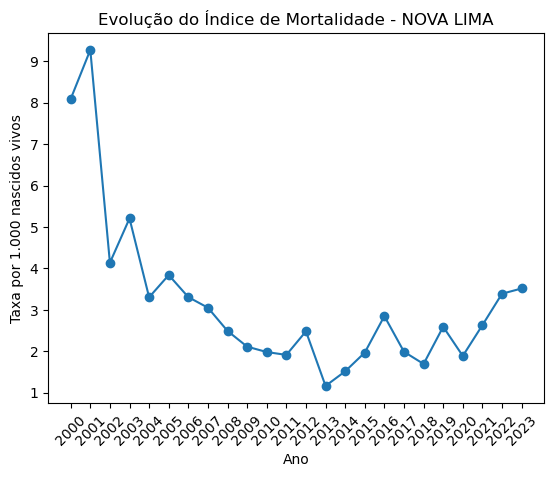

In [300]:
df_araponga = df_join[df_join["nome_do_municipio"] == "NOVA LIMA"]
plt.plot(df_araponga["ANO"], df_araponga["taxa_de_mortalidade_infantil"], marker='o')
plt.title("Evolução do Índice de Mortalidade - NOVA LIMA")
plt.xlabel("Ano")
plt.ylabel("Taxa por 1.000 nascidos vivos")
plt.xticks(rotation=45)
plt.show()

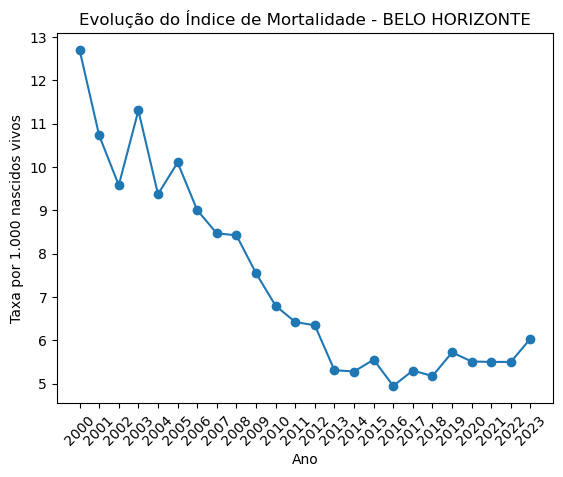

In [301]:
df_araponga = df_join[df_join["nome_do_municipio"] == "BELO HORIZONTE"]
plt.plot(df_araponga["ANO"], df_araponga["taxa_de_mortalidade_infantil"], marker='o')
plt.title("Evolução do Índice de Mortalidade - BELO HORIZONTE")
plt.xlabel("Ano")
plt.ylabel("Taxa por 1.000 nascidos vivos")
plt.xticks(rotation=45)
plt.show()

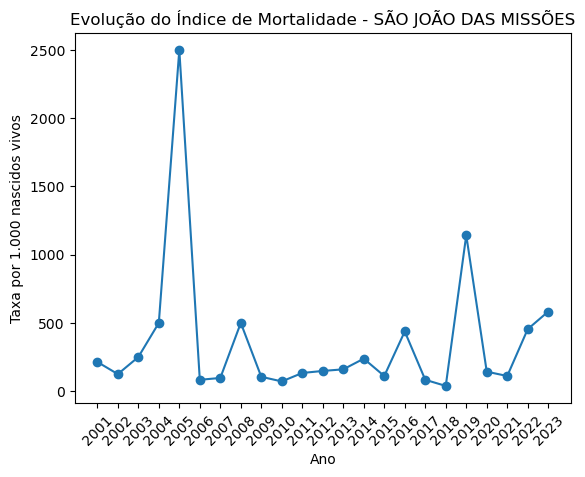

In [302]:
df_araponga = df_join[df_join["nome_do_municipio"] == "SÃO JOÃO DAS MISSÕES"]
plt.plot(df_araponga["ANO"], df_araponga["taxa_de_mortalidade_infantil"], marker='o')
plt.title("Evolução do Índice de Mortalidade - SÃO JOÃO DAS MISSÕES")
plt.xlabel("Ano")
plt.ylabel("Taxa por 1.000 nascidos vivos")
plt.xticks(rotation=45)
plt.show()

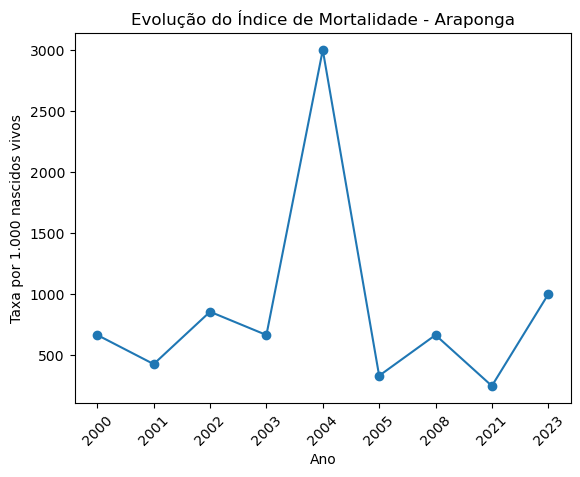

In [303]:
df_araponga = df_join[df_join["nome_do_municipio"] == "ARAPONGA"]
plt.plot(df_araponga["ANO"], df_araponga["taxa_de_mortalidade_infantil"], marker='o')
plt.title("Evolução do Índice de Mortalidade - Araponga")
plt.xlabel("Ano")
plt.ylabel("Taxa por 1.000 nascidos vivos")
plt.xticks(rotation=45)
plt.show()

## Gráfico de dispersão - nascimentos x óbitos 

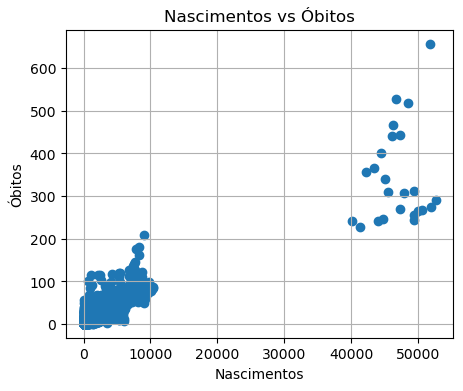

In [304]:
plt.figure(figsize=(5,4))
plt.scatter(df_join["n_nascimentos"], df_join["n_obitos"])
plt.title("Nascimentos vs Óbitos")
plt.xlabel("Nascimentos"); plt.ylabel("Óbitos"); plt.grid(True, axis="both")
plt.show()